<a href="https://colab.research.google.com/github/bradfordj5820-ai/customer-sentiment-analyzer/blob/main/Customer_Feedback.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

sentiment    Negative  Neutral  Positive
city                                    
Austin              2        1         1
Dallas              1        1         2
El Paso             0        2         0
Fort Worth          1        1         0
Houston             1        2         1
San Antonio         2        1         1


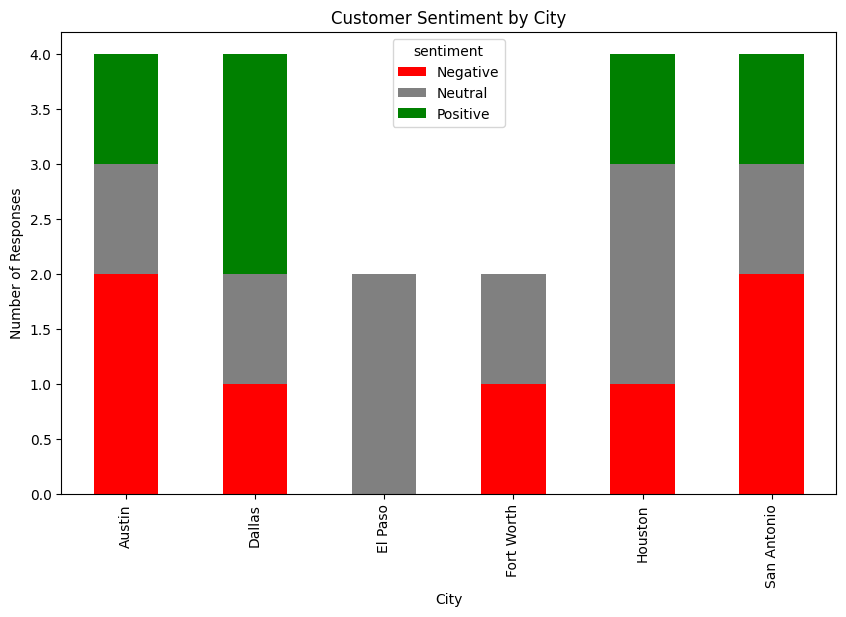

In [18]:
#Gather and import Customer Data

import pandas as pd
from dataclasses import dataclass
import matplotlib.pyplot as plt

# Load and Merge Data
customers = pd.read_csv('/content/drive/MyDrive/Python Data Files/Customer_Data.csv')
feedback = pd.read_csv('/content/drive/MyDrive/Python Data Files/customer_feedback.csv')
merged_data = pd.merge(customers, feedback, on='name')

# Rename DataFrame columns to match dataclass field names (case-insensitive issue)
df.rename(columns={'Name': 'name', 'Age': 'age', 'City': 'city'}, inplace=True)

#print(df.head())

@dataclass #Establish a data class to facilitate effective data processing
class Customer:
    name: str
    age: str
    city: str

customer_list =[Customer(**row.to_dict()) for index, row in df.iterrows()] #Distribute customer data into Customer class


#Analyze Customer Feedback

def get_sentiment(text):
    text = text.lower()
    pos = ['good', 'excellent', 'great', 'amazing', 'professional']
    neg = ['bad', 'poor', 'terrible', 'slow', 'worst']

    if any(w in text for w in pos): return 'Positive'
    if any(w in text for w in neg): return 'Negative'
    return 'Neutral'

merged_data['sentiment'] = merged_data['feedback'].apply(get_sentiment)
merged_data.to_csv('analyzed_customer_feedback.csv', index=False)

#Generate Summary Report

report = merged_data.groupby(['city', 'sentiment']).size().unstack(fill_value=0)

report.plot(kind='bar', stacked=True, figsize=(10,6), color=['red', 'gray', 'green'])

plt.title('Customer Sentiment by City')
plt.ylabel('Number of Responses')
plt.xlabel('City')

plt.savefig('sentiment_report_by_city.png')


#Organize and Display Data
print(report)
plt.savefig('sentiment_report_by_city.png')
plt.show()